In [5]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import h5py
from torch.utils.data import Dataset
import torchvision.transforms as T

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


In [6]:
with h5py.File('3dshapes.h5', 'r') as f:
    imgs   = f['images'][:]
    labels = f['labels'][:]

print('Images:', imgs.shape, imgs.dtype)
print('Labels:', labels.shape)

Images: (480000, 64, 64, 3) uint8
Labels: (480000, 6)


In [7]:
class Shapes3DDataset(Dataset):
    def __init__(self, images):
        self.images = images
        self.transform = T.ToTensor()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.transform(self.images[idx])


class VAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.ReLU(),
            nn.Flatten(),
        )
        self.fc_mu     = nn.Linear(4096, latent_dim)
        self.fc_logvar = nn.Linear(4096, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, 4096)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (256, 4, 4)),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def decode(self, z):
        return self.decoder(self.fc_decode(z))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


dataset = Shapes3DDataset(imgs)
print('Dataset ready.')

Dataset ready.


In [8]:
import os

ckpt_path = 'beta_1.pt'
print('File exists:', os.path.exists(ckpt_path))
print('Working directory:', os.getcwd())
print('Files here:', [f for f in os.listdir('.') if f.endswith('.pt') or f.endswith('.h5')])

ckpt = torch.load(ckpt_path, map_location=device)
# beta_*.pt checkpoints (saved by the disentanglement sweep) don't store
# 'latent_dim' like vae_trained.pt does -- infer it from fc_mu's weight shape instead.
latent_dim = ckpt.get('latent_dim', ckpt['model_state']['fc_mu.weight'].shape[0])
model = VAE(latent_dim=latent_dim).to(device)
model.load_state_dict(ckpt['model_state'])
model.eval()

w = list(model.parameters())[0]
print(f'\nFirst conv weight — mean: {w.mean().item():.6f}  std: {w.std().item():.6f}')
print('(random init would have std ~0.08; trained model will differ)')

File exists: True
Working directory: /Users/perica/Documents/GitHub/Disentanglement-and--VAE
Files here: ['beta_10.pt', 'beta_8.pt', '3dshapes.h5', 'beta_6.pt', 'beta_2.pt', 'celeba_vae_trained.pt', 'beta_1.pt', 'beta_4.pt', 'vae_trained.pt']

First conv weight — mean: -0.027962  std: 0.105297
(random init would have std ~0.08; trained model will differ)


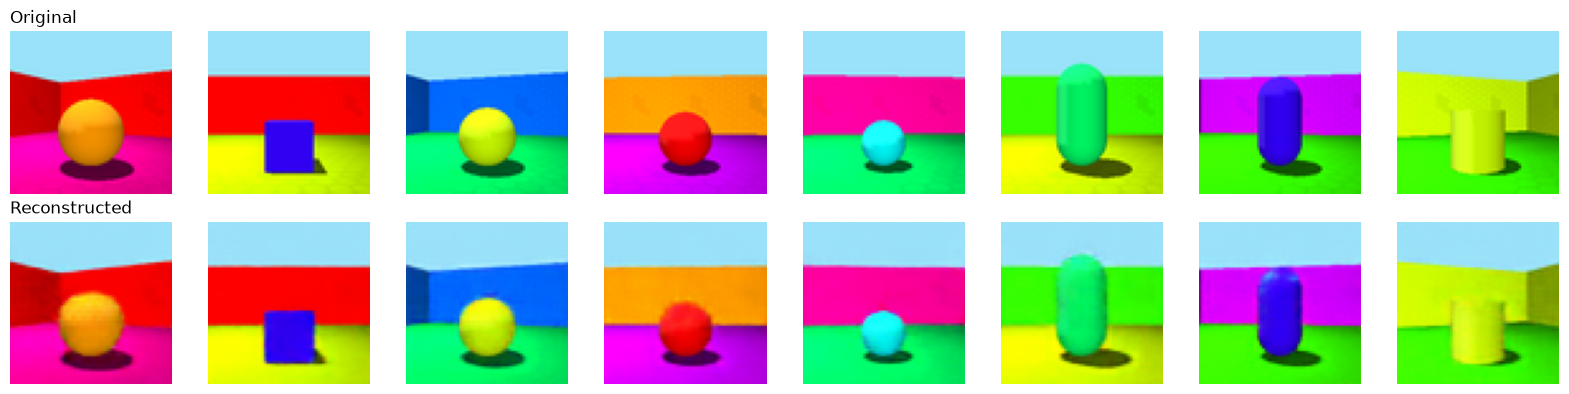

In [9]:
indices = np.random.randint(0, len(dataset), size=8)
batch = torch.stack([dataset[i] for i in indices]).to(device)

with torch.no_grad():
    recon, _, _ = model(batch)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(batch[i].cpu().permute(1, 2, 0))
    axes[0, i].axis('off')
    axes[1, i].imshow(recon[i].cpu().permute(1, 2, 0))
    axes[1, i].axis('off')

axes[0, 0].set_title('Original', loc='left', fontsize=12)
axes[1, 0].set_title('Reconstructed', loc='left', fontsize=12)
plt.tight_layout()
plt.show()

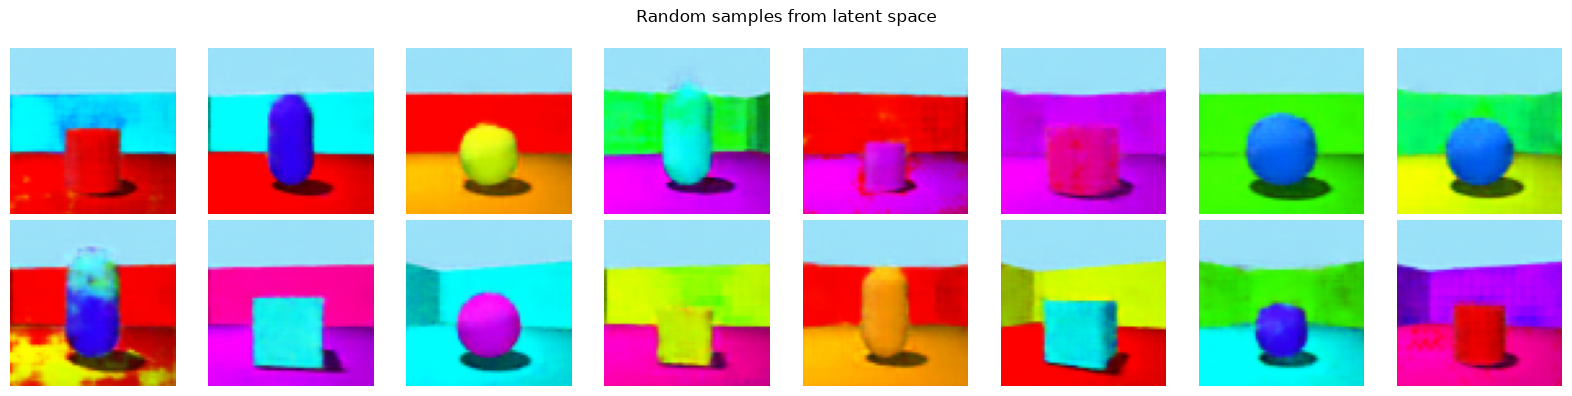

In [10]:
model.eval()
with torch.no_grad():
    z = torch.randn(16, 16).to(device)  # 16 random points from N(0,1)
    samples = model.decode(z)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(samples[i].cpu().permute(1, 2, 0))
    ax.axis('off')

plt.suptitle('Random samples from latent space')
plt.tight_layout()
plt.show()